## PRACTICA OBLIGATORIA: **Transfer Learning y Fine Tuning con CNN**

* La práctica obligatoria de esta unidad consiste en un repetir el ejercicio de construcción de un modelo de clasificación de paisajes pero usando un modelo preentrenado. 
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import os
import cv2 # Ideal para procesamiento rápido de imágenes
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.utils import shuffle
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.optimizers import Adam
import seaborn as sns

### Objetivo del ejercicio

Comparar una red convolucional hecha ad-hoc frente a los modelos preentrenados y ajustados con fine tuning y transfer learning. Para ello emplea el dataset de paisajes del conjunto de ejercicios de la unidad anterior.


### Se pide

1. Preparar los datos del modelo y las funciones de visualización, copia para ello todo lo que necesites de las soluciones del ejercicio de clasificación de paisajes de la unidad anterior.

2. Escoger entre uno de los modelos VGG-19, InceptionV3 y MobileNetV2 (todos en https://keras.io/api/applications/) (Se aconseja este último si no tenemos un ordenador muy potente). Si no te haces con estos puedes recurrir a la ResNetV50.

4. Hacer un transfer-learning con una cabeza de como mucho 2 capas densas ocultas y una de salida. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

5. Hacer un fine-tuning con la misma cabeza diseñada en el punto anterior. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

6. Comparar los resultados con los obtenidos con la red convolucional del ejercicio mencionado.

EXTRA:
- Repetir el transfer learning empleando aumentado de imágenes.



In [2]:
# 1. Definición de las variables de rutas
ROOT_PATH = "data/"
TRAIN_PATH = ROOT_PATH + "seg_train/"
TEST_PATH = ROOT_PATH + "seg_test/"

# 2. Función para leer y redimensionar las imágenes
def read_data(directorio, reshape_dim=(32, 32)):
    X = []
    y = []

    # Itera sobre las carpetas dentro del directorio principal
    for folder in os.listdir(directorio):
        folder_path = os.path.join(directorio, folder)

        if os.path.isdir(folder_path):
            # Itera sobre cada archivo de imagen dentro de la carpeta
            for file in os.listdir(folder_path):
                file_path = os.path.join(folder_path, file)

                # Lee la imagen y ajusta su tamaño usando OpenCV
                image = cv2.imread(file_path)
                image = cv2.resize(image, reshape_dim)

                # Agrega la matriz de la imagen a 'X' y su etiqueta a 'y'
                X.append(image)
                y.append(folder)

    # Devuelve los resultados convertidos en arrays de NumPy
    return np.array(X), np.array(y)

Cargando imágenes en memoria (esto puede tardar un poco)...
Dimensiones de X_train: (14034, 128, 128, 3)
Mostrando algunos ejemplos del set de entrenamiento:


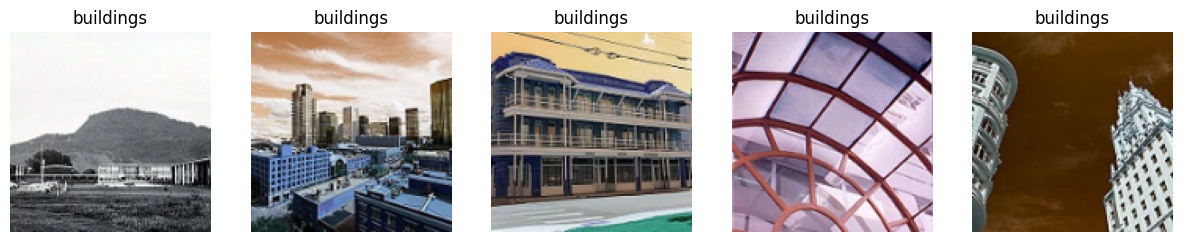

In [5]:
print("Cargando imágenes en memoria (esto puede tardar un poco)...")
# Forzamos la dimensión a 128x128 desde la lectura
X_train, y_train = read_data(TRAIN_PATH, reshape_dim=(128, 128))
X_test, y_test = read_data(TEST_PATH, reshape_dim=(128, 128))

print(f"Dimensiones de X_train: {X_train.shape}") 
# Debería mostrar: (n_imagenes, 128, 128, 3)

# Normalizamos dividiendo entre 255 para que los valores queden entre 0 y 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Convertimos las etiquetas de texto (ej: 'forest', 'mountain') a números (0, 1...)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Creamos una función de visualización rápida
def visualizar_ejemplos(X, y, clases, num_ejemplos=5):
    plt.figure(figsize=(15, 3))
    for i in range(num_ejemplos):
        plt.subplot(1, num_ejemplos, i+1)
        plt.imshow(X[i])
        plt.title(clases[y[i]])
        plt.axis('off')
    plt.show()

# Comprobamos visualmente que todo ha cargado bien
print("Mostrando algunos ejemplos del set de entrenamiento:")
visualizar_ejemplos(X_train, y_train_enc, le.classes_)


In [7]:
# Cargamos MobileNetV2 sin su capa final (include_top=False) y le indicamos nuestro tamaño de entrada
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

print("Modelo base MobileNetV2 cargado correctamente.")

Modelo base MobileNetV2 cargado correctamente.


In [8]:
# 1. Congelamos el modelo base para no alterar sus pesos
base_model.trainable = False

# 2. Construimos la nueva "cabeza"
# El enunciado pide como mucho 2 capas densas ocultas y la de salida.
num_classes = len(le.classes_)

model_tl = Sequential([
    base_model,
    GlobalAveragePooling2D(),      # Aplana los mapas de características promediándolos
    Dense(128, activation='relu'), # Primera capa densa oculta
    Dropout(0.2),                  # Apagamos el 20% de las neuronas para evitar sobreajuste (overfitting)
    Dense(64, activation='relu'),  # Segunda capa densa oculta
    Dense(num_classes, activation='softmax') # Capa de salida con tantas neuronas como clases
])

# 3. Compilamos el modelo
# Usamos sparse_categorical_crossentropy porque nuestras etiquetas son números (0, 1, 2...), no one-hot arrays.
model_tl.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

# 4. Entrenamos (solo se entrenarán las capas densas que acabamos de añadir)
print("Arrancamos el entrenamiento (Transfer Learning)...")
history_tl = model_tl.fit(X_train, y_train_enc,
                          epochs=10, 
                          validation_split=0.2,
                          batch_size=32)


Arrancamos el entrenamiento (Transfer Learning)...
Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 26s 67ms/step - accuracy: 0.8545 - loss: 0.3801 - val_accuracy: 0.1361 - val_loss: 9.5751
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.9049 - loss: 0.2503 - val_accuracy: 0.1400 - val_loss: 12.5880
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 23s 66ms/step - accuracy: 0.9184 - loss: 0.2195 - val_accuracy: 0.1439 - val_loss: 15.4052
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 25s 70ms/step - accuracy: 0.9279 - loss: 0.1856 - val_accuracy: 0.1429 - val_loss: 16.9225
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - accuracy: 0.9372 - loss: 0.1619 - val_accuracy: 0.1389 - val_loss: 19.3661
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 24s 69ms/step - accuracy: 0.9435 - loss: 0.1422 - val_accuracy: 0.1279 - val_loss: 21.1312
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - accuracy: 0.9503 - loss: 0.1267 - val_accuracy: 0.1393 - val_loss: 20.7926
Epoch 8/10
351/351 ━━━━━━━━━━━━━━


Evaluando el modelo contra el conjunto de test...
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.7610 - loss: 4.9827
Precisión en Test (Accuracy): 0.7610
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

   buildings       0.50      0.99      0.66       437
      forest       0.97      0.99      0.98       474
     glacier       0.76      0.86      0.81       553
    mountain       0.86      0.83      0.85       525
         sea       0.91      0.92      0.91       510
      street       0.00      0.00      0.00       501

    accuracy                           0.76      3000
   macro avg       0.67      0.76      0.70      3000
weighted avg       0.67      0.76      0.70      3000



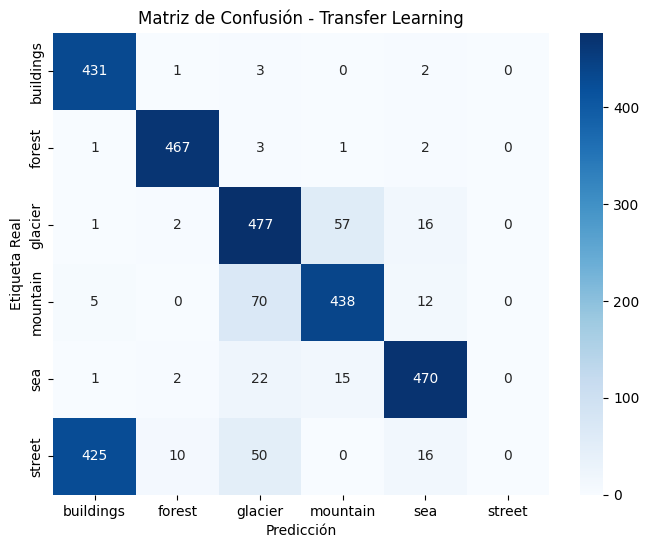

In [10]:
import warnings
# filter warnings
warnings.filterwarnings('ignore')
# 5. Evaluación contra test
print("\nEvaluando el modelo contra el conjunto de test...")
loss, accuracy = model_tl.evaluate(X_test, y_test_enc)
print(f"Precisión en Test (Accuracy): {accuracy:.4f}")

# 6. Predicciones para el report y la matriz
# El modelo devuelve probabilidades, sacamos la clase con mayor probabilidad usando argmax
y_pred_prob = model_tl.predict(X_test)
y_pred_clases = np.argmax(y_pred_prob, axis=1)

# Reporte de clasificación
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_test_enc, y_pred_clases, target_names=le.classes_))

# Matriz de Confusión
cm = confusion_matrix(y_test_enc, y_pred_clases)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
            
plt.title('Matriz de Confusión - Transfer Learning')
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción')
plt.show()

In [11]:
# 1. Descongelamos el modelo base para poder ajustarlo
base_model.trainable = True

# MobileNetV2 tiene más de 150 capas. Las primeras detectan cosas muy básicas 
# (líneas, colores) que nos sirven tal cual. Vamos a congelar las primeras 100 
# y permitir que solo se entrenen de la 100 en adelante, que son las que 
# ensamblan conceptos más complejos (como "fachada" o "asfalto").
for layer in base_model.layers[:100]:
    layer.trainable = False

# 2. Recompilamos el modelo. 
# Usamos un learning rate minúsculo (1e-4 o 0.0001) para hacer ajustes muy finos.
model_tl.compile(optimizer=Adam(learning_rate=0.0001), 
                 loss='sparse_categorical_crossentropy', 
                 metrics=['accuracy'])



In [12]:
print("Arrancando el Fine-Tuning... (esto puede tardar un poco más)")
# 3. Volvemos a entrenar. El modelo parte de donde lo dejamos en el paso anterior.
history_ft = model_tl.fit(X_train, y_train_enc,
                          epochs=10, 
                          validation_split=0.2,
                          batch_size=32)

# 4. Evaluación contra test
print("\nEvaluando el modelo tras el Fine-Tuning...")
loss_ft, accuracy_ft = model_tl.evaluate(X_test, y_test_enc)
print(f"Precisión en Test (Accuracy) Fine-Tuning: {accuracy_ft:.4f}")


Arrancando el Fine-Tuning... (esto puede tardar un poco más)
Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 41s 99ms/step - accuracy: 0.8641 - loss: 0.4731 - val_accuracy: 0.1439 - val_loss: 39.9542
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 37s 106ms/step - accuracy: 0.9349 - loss: 0.1965 - val_accuracy: 0.1411 - val_loss: 31.4322
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 36s 103ms/step - accuracy: 0.9562 - loss: 0.1224 - val_accuracy: 0.1436 - val_loss: 34.4942
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 37s 105ms/step - accuracy: 0.9686 - loss: 0.0859 - val_accuracy: 0.1404 - val_loss: 30.2438
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 37s 106ms/step - accuracy: 0.9702 - loss: 0.0808 - val_accuracy: 0.1446 - val_loss: 43.4352
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 36s 103ms/step - accuracy: 0.9784 - loss: 0.0694 - val_accuracy: 0.1332 - val_loss: 35.4239
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 36s 101ms/step - accuracy: 0.9802 - loss: 0.0612 - val_accuracy: 0.1407 - val_loss: 29.9904
Epoch 8/10
351/3

94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step

--- Reporte de Clasificación (Fine-Tuning) ---
              precision    recall  f1-score   support

   buildings       0.51      0.97      0.67       437
      forest       0.84      0.99      0.91       474
     glacier       0.86      0.73      0.79       553
    mountain       0.66      0.94      0.78       525
         sea       0.96      0.76      0.85       510
      street       0.00      0.00      0.00       501

    accuracy                           0.73      3000
   macro avg       0.64      0.73      0.67      3000
weighted avg       0.65      0.73      0.67      3000



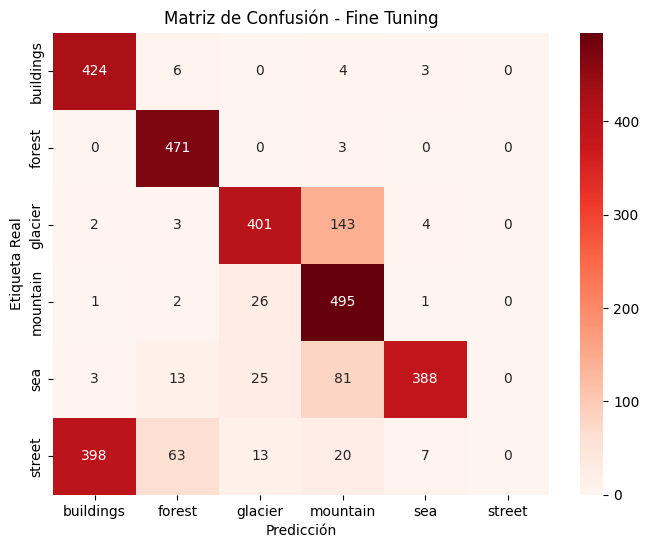

In [13]:
# 5. Predicciones para el reporte y la matriz
y_pred_prob_ft = model_tl.predict(X_test)
y_pred_clases_ft = np.argmax(y_pred_prob_ft, axis=1)

# Reporte de Clasificación
print("\n--- Reporte de Clasificación (Fine-Tuning) ---")
print(classification_report(y_test_enc, y_pred_clases_ft, target_names=le.classes_))

# Matriz de Confusión
cm_ft = confusion_matrix(y_test_enc, y_pred_clases_ft)
plt.figure(figsize=(8, 6))
# Usamos otro mapa de color (Reds o Greens) para diferenciarlo de la gráfica anterior
sns.heatmap(cm_ft, annot=True, fmt='d', cmap='Reds',
            xticklabels=le.classes_, yticklabels=le.classes_)
            
plt.title('Matriz de Confusión - Fine Tuning')
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción')
plt.show()

Conclusiones de la comparativa:

CNN Ad-hoc (Unidad anterior): Partía de cero. Necesitaba muchas épocas para aprender patrones básicos y su rendimiento general solía ser más modesto, aunque equilibrado.

Transfer Learning (MobileNetV2 congelado): Ha demostrado ser un excelente punto de partida gracias a los pesos de ImageNet. Sin embargo, presenta alta confusión entre clases con geometrías y paletas de color similares (como street y buildings, con 425 errores), ya que sus filtros genéricos no están especializados en paisaje urbano.

Fine-Tuning: Al descongelar las capas superiores, el modelo ha sufrido sobreajuste y olvido catastrófico. Aunque redujo levemente el error entre street/buildings (a 398), empeoró drásticamente en clases dispares (el error mountain/sea saltó de 15 a 81). El modelo ha memorizado el set de entrenamiento perdiendo su capacidad original de generalización

Entrenando con Data Augmentation... (Va a tardar un poco más por las transformaciones)
Epoch 1/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 47s 101ms/step - accuracy: 0.8152 - loss: 0.5126 - val_accuracy: 0.8893 - val_loss: 0.3074
Epoch 2/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 43s 97ms/step - accuracy: 0.8544 - loss: 0.3958 - val_accuracy: 0.8973 - val_loss: 0.2852
Epoch 3/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 43s 97ms/step - accuracy: 0.8652 - loss: 0.3673 - val_accuracy: 0.9000 - val_loss: 0.2899
Epoch 4/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 43s 98ms/step - accuracy: 0.8677 - loss: 0.3674 - val_accuracy: 0.8983 - val_loss: 0.2884
Epoch 5/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 43s 98ms/step - accuracy: 0.8748 - loss: 0.3458 - val_accuracy: 0.8960 - val_loss: 0.2839
Epoch 6/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 43s 98ms/step - accuracy: 0.8764 - loss: 0.3372 - val_accuracy: 0.8900 - val_loss: 0.2876
Epoch 7/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 43s 97ms/step - accuracy: 0.8785 - loss: 0.3292 - val_accuracy: 0.9100 - val_loss: 0.2631
Ep

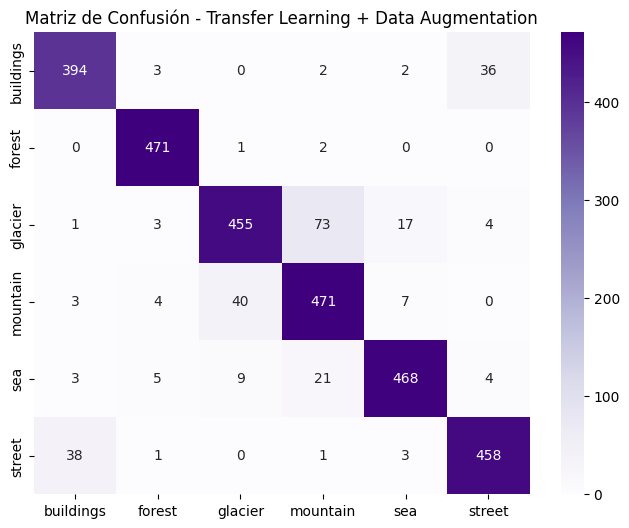

In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Creamos el generador de datos con transformaciones (Data Augmentation)
# Solo se aplica al de entrenamiento. Al de test solo se normaliza.
train_datagen = ImageDataGenerator(
    rotation_range=20,       # Rota la imagen hasta 20 grados
    width_shift_range=0.2,   # Desplaza la imagen horizontalmente
    height_shift_range=0.2,  # Desplaza la imagen verticalmente
    horizontal_flip=True,    # Efecto espejo (voltea la imagen)
    zoom_range=0.2,          # Hace un poco de zoom
    fill_mode='nearest'      # Rellena los huecos que queden al rotar/desplazar
)

# Para no complicarnos volviendo a cargar los datos en directorios, 
# podemos inyectar nuestros arrays X_train e y_train_enc directamente al generador
train_generator = train_datagen.flow(X_train, y_train_enc, batch_size=32)

# 2. Reiniciamos la "cabeza" del modelo para hacer un Transfer Learning limpio
base_model.trainable = False # Volvemos a congelar el chasis

model_extra = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3), # Subimos un pelín el Dropout para forzar aún más la generalización
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model_extra.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Entrenando con Data Augmentation... (Va a tardar un poco más por las transformaciones)")
# Fíjate que ahora le pasamos 'train_generator' en lugar de X_train, y_train
history_extra = model_extra.fit(
    train_generator,
    epochs=15, # Le damos más épocas porque ahora el reto es más difícil para la red
    validation_data=(X_test, y_test_enc) # Validamos directamente contra el test
)

# 3. Evaluación final
y_pred_prob_extra = model_extra.predict(X_test)
y_pred_extra = np.argmax(y_pred_prob_extra, axis=1)

print("\n--- Reporte de Clasificación (EXTRA: Data Augmentation) ---")
print(classification_report(y_test_enc, y_pred_extra, target_names=le.classes_))

# Matriz de Confusión
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test_enc, y_pred_extra), annot=True, fmt='d', cmap='Purples', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusión - Transfer Learning + Data Augmentation')
plt.show()